# Dynamic Conditional Correlation Modelling 

*By Vlad Popa*

Squared returns act as a proxy for time-varying variance $\sigma^2_t$. By means of the ACF Test, it is revealed that the variance of returns in certain periods tend to cluster together rather than occur randomly. This phenomenon is known as **volatility clustering**, and plays a significant role in risk management, derivative pricing and algorithmic trading because it proves that market volatility is not entirely random. By means of **observation-driven models**, which estimate unobserved time-varying parameters using lagged dependent variables, volatility clustering can be captured.

This project investigates volatility clustering by assessing the time-varying, conditional correlation between several assets, driven by geopolitical choke points in 2026 using the DCC-GARCH(1,1) model.

## 1. Import Libraries and Load Data

In [9]:
# Import libraries
library(rugarch)
library(rmgarch)
library(purrr)
library(ggplot2)
library(tidyr)
library(reshape2)
library(dplyr)

# Read .csv files
bdi <- read.csv("input/mod/Modified Baltic Dry Index Historical Data.csv")
oil <- read.csv("input/mod/Modified Crude Oil WTI Futures Historical Data.csv")
soxx <- read.csv("input/mod/Modified SOXX ETF Stock Price History.csv")
urth <- read.csv("input/mod/Modified URTH ETF Stock Price History.csv")
gold <- read.csv("input/mod/Modified XAU_USD Historical Data.csv")

In [10]:
# Save returns of each asset to a separate dataframe
bdi_rets <- data.frame(Date = bdi$Date,  BDI = bdi$Return)
oil_rets <- data.frame(Date = oil$Date,  OIL = oil$Return)
soxx_rets <- data.frame(Date = soxx$Date, SOXX = soxx$Return)
urth_rets <- data.frame(Date = urth$Date, URTH = urth$Return)
gold_rets <- data.frame(Date = gold$Date, GOLD = gold$Return)

# Save all dataframes to a list
rets_list <- list(bdi_rets, oil_rets, soxx_rets, urth_rets, gold_rets)

# Sequentially merge each dataframe on the 'Date' column
returns_scaled <- purrr::reduce(rets_list, merge, by = "Date")
rownames(returns_scaled) <- returns_scaled$Date
returns_scaled$Date <- NULL

## 2. DCC-GARCH Model

The **DCC-GARCH model** is an extended, multivariate variant of an observation-driven model. It computes the conditional covariance matrix $\Sigma_t$ using lagged dependent variables, while also modelling the time-varying conditional correlation between the assets based on their conditional volatility. Unlike other multivariate GARCH models, the DCC extension allows for co-dependencies when computing covariances, a small dimensionality, and a positive definite covariance matrix $\Sigma_t$. We bring the model together in the two sections below.

### 2.a GARCH Modelling

The first step of modelling the DCC-GARCH involves estimating an univariate GARCH model for each asset. In other words, we extract the behaviour of each individual asset's conditional variance. We do so by estimating the Exponential GARCH(1,1) Model (eGARCH(1,1)) on each asset, which also captures any asymmetric leverage effects (using $\gamma_i$) and ensures that an asset's variance never goes negative (though $\ln{(.)}$), as to obtain: $$\ln{(\sigma^2_{i,t})}=\omega_{i}+\beta_{i}\ln{(\sigma^2_{i,t-1})}+\alpha_{i}|\frac{y_{i,t-1}}{\sigma_{i,t-1}}| + \gamma_i \frac{y_{i,t-1}}{\sigma_{i,t-1}} \text{ for each asset } i \text{ in } i = 1,2,...$$

In [11]:
# Function for modelling conditional volatilities using eGARCH
my_garch <- function(returns_scaled){
    # Specify our GARCH model: how do individual variances behave?
    uspec <- ugarchspec(
        mean.model = list(armaOrder = c(0,0), include.mean = FALSE),
        variance.model = list(model = "eGARCH"),
        distribution.model = "std")

    # Replicate the univariate GARCH model across all assets
    mspec <- multispec(replicate(ncol(returns_scaled), uspec))       

    # Estimate all conditional volatilities using our defined GARCH model
    fitlist <- multifit(multispec = mspec, data = returns_scaled)
    sigmas <- sigma(fitlist)
    rownames(sigmas) <- rownames(returns_scaled)
    colnames(sigmas) <- colnames(returns_scaled)
    sigmas <- as.data.frame(sigmas)

    # Save specifications, fits and conditional volatilities together
    output = list(
        sigmas = sigmas,
        mspec = mspec,
        fitlist = fitlist
    )
    return (output)
}

# Run function and save conditional volatilites
ugarch_results <- my_garch(returns_scaled) 
sigmas <- ugarch_results[["sigmas"]]
mspec <- ugarch_results[["mspec"]]
fitlist <- ugarch_results[["fitlist"]]
head(sigmas)

Warning message in .egarchfit(spec = spec, data = data, out.sample = out.sample, :
"
ugarchfit-->warning: solver failer to converge."
Warning message in .egarchfit(spec = spec, data = data, out.sample = out.sample, :
"
ugarchfit-->warning: solver failer to converge."
Warning message in .egarchfit(spec = spec, data = data, out.sample = out.sample, :
"
ugarchfit-->warning: solver failer to converge."


,BDI,OIL,SOXX,URTH,GOLD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2016-01-03,11.68716,5.950680,4.225209,2.342157,2.123443
2016-01-10,11.97517,7.679031,6.471575,4.846060,2.327910
2016-01-17,12.69780,9.086894,6.465528,4.612748,2.256769
2016-01-24,11.76427,8.477064,5.642891,3.720677,2.250155
2016-01-31,12.06487,7.591659,4.974643,3.085702,2.302344
2016-02-07,11.53046,8.248618,5.380009,3.499089,2.557108


### 2.b DCC Modelling

In this next step, we utilize the univariate eGARCH specifications from the previous section as well as the fitted data for each asset. By means of the DCC framework, we use those outputs as inputs for modelling the conditional correlation matrix based on standardized returns. In mathematical notation, we compute: 
$$Q_t = (1 - \alpha - \beta)\bar{Q} + \alpha(v_{t-1}v_{t-1}') + \beta Q_{t-1}$$

Where $v_t = \frac{y_t}{\sigma_t}$ represents the vector of standardized returns of all assets, and $\bar{Q}$ is the unconditional covariance matrix of the standardized residuals over the entire sample period. 

To ensure the elements are strictly bounded between $-1$ and $1$, the final conditional correlation matrix $R_t$ is rescaled as:

$$R_t = \text{diag}(Q_t)^{-1/2} Q_t \text{diag}(Q_t)^{-1/2}$$

In [12]:
# Function for modelling dynamic correlations between assets
my_dcc <- function(returns_scaled, mspec, fitlist){
    # Specify our DCC model: how do the correlations behave?
    dcc_spec <- dccspec(uspec = mspec, dccOrder = c(1,1), model = "DCC")
    dcc_fit <- dccfit(spec = dcc_spec, data = returns_scaled, fit = fitlist)
    corr_matrix <- rcor(dcc_fit)
    return (corr_matrix)
}

# Run function and save conditional correlation matrix
corr_matrix <- my_dcc(returns_scaled, mspec, fitlist) 

## 3. Results
We display the results of our analysis in three plots: 
1. A time series plot displaying the conditional variance of each asset throughout the data.
2. A time series plot displaying the conditional correlation between each asset throughout the data. 
3. A heat map showcasing the conditional correlation between each asset across Iran-US conflict pre-event, escalation and stabilization.


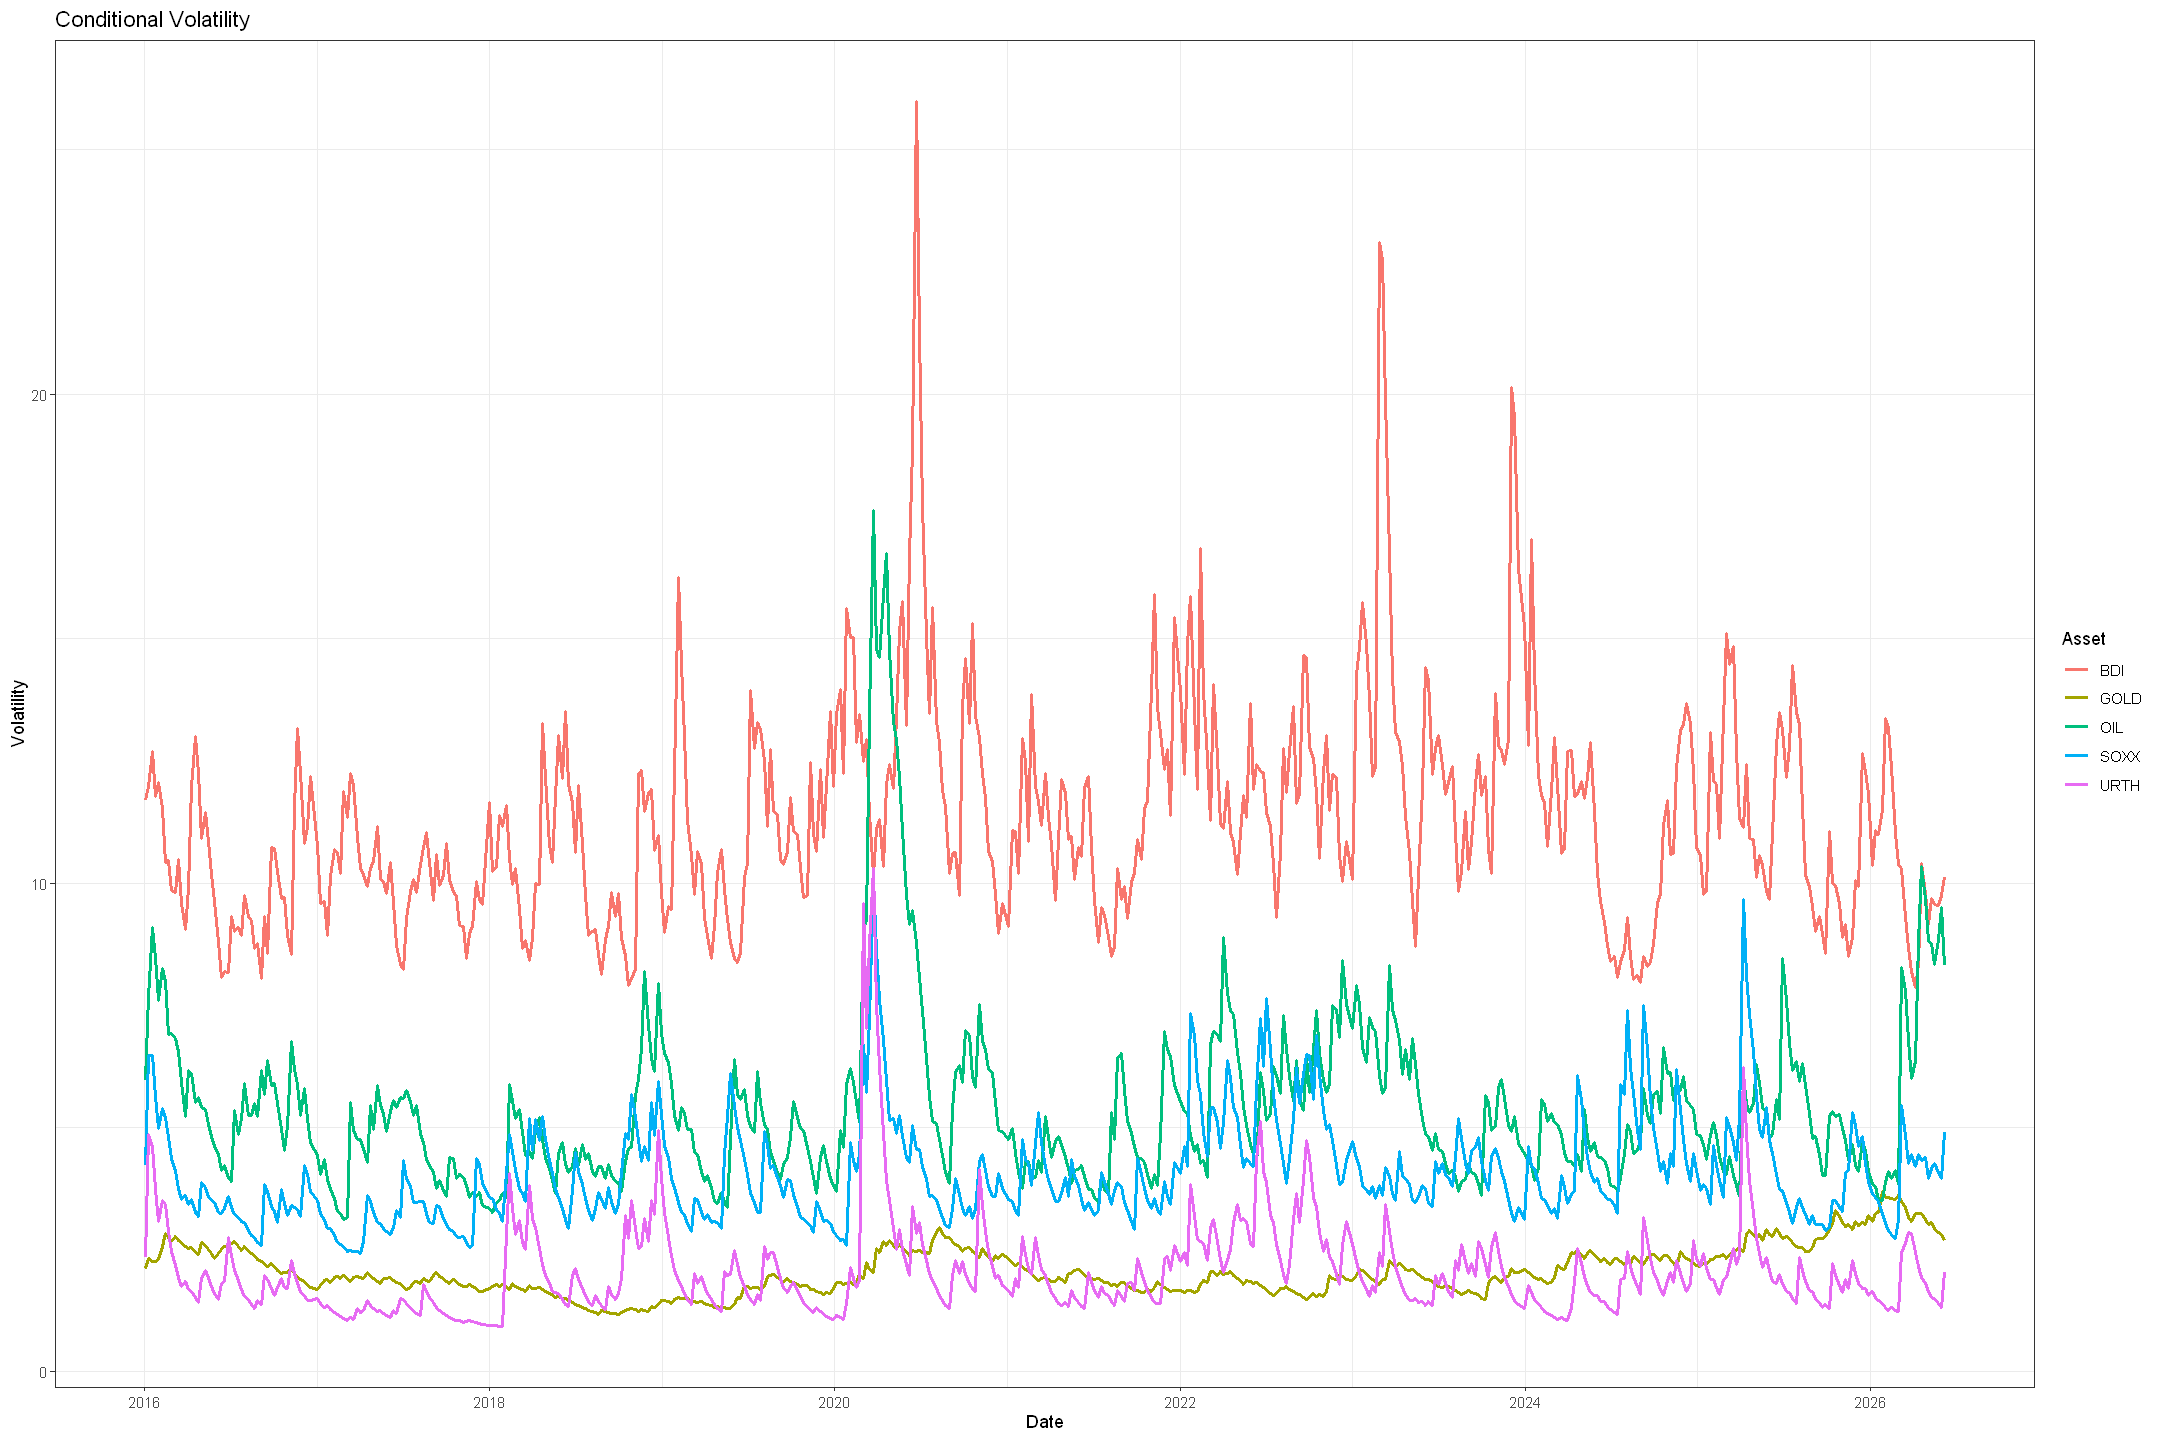

In [13]:
# Convert sigmas dataframe to "longer" dataframe
sigmas$Date <- as.Date(rownames(sigmas))
sigmas_long <- sigmas %>%
    pivot_longer(
        cols = -Date,
        names_to = "Asset",
        values_to = "Var_T"
    )

# Time series plot of conditional variances     
ggplot(sigmas_long, aes(x = Date, y = Var_T, color = Asset)) + 
    labs(title = "Conditional Volatility", x = "Date", y = "Volatility") + 
    geom_line(size = 1) + 
    theme_bw()

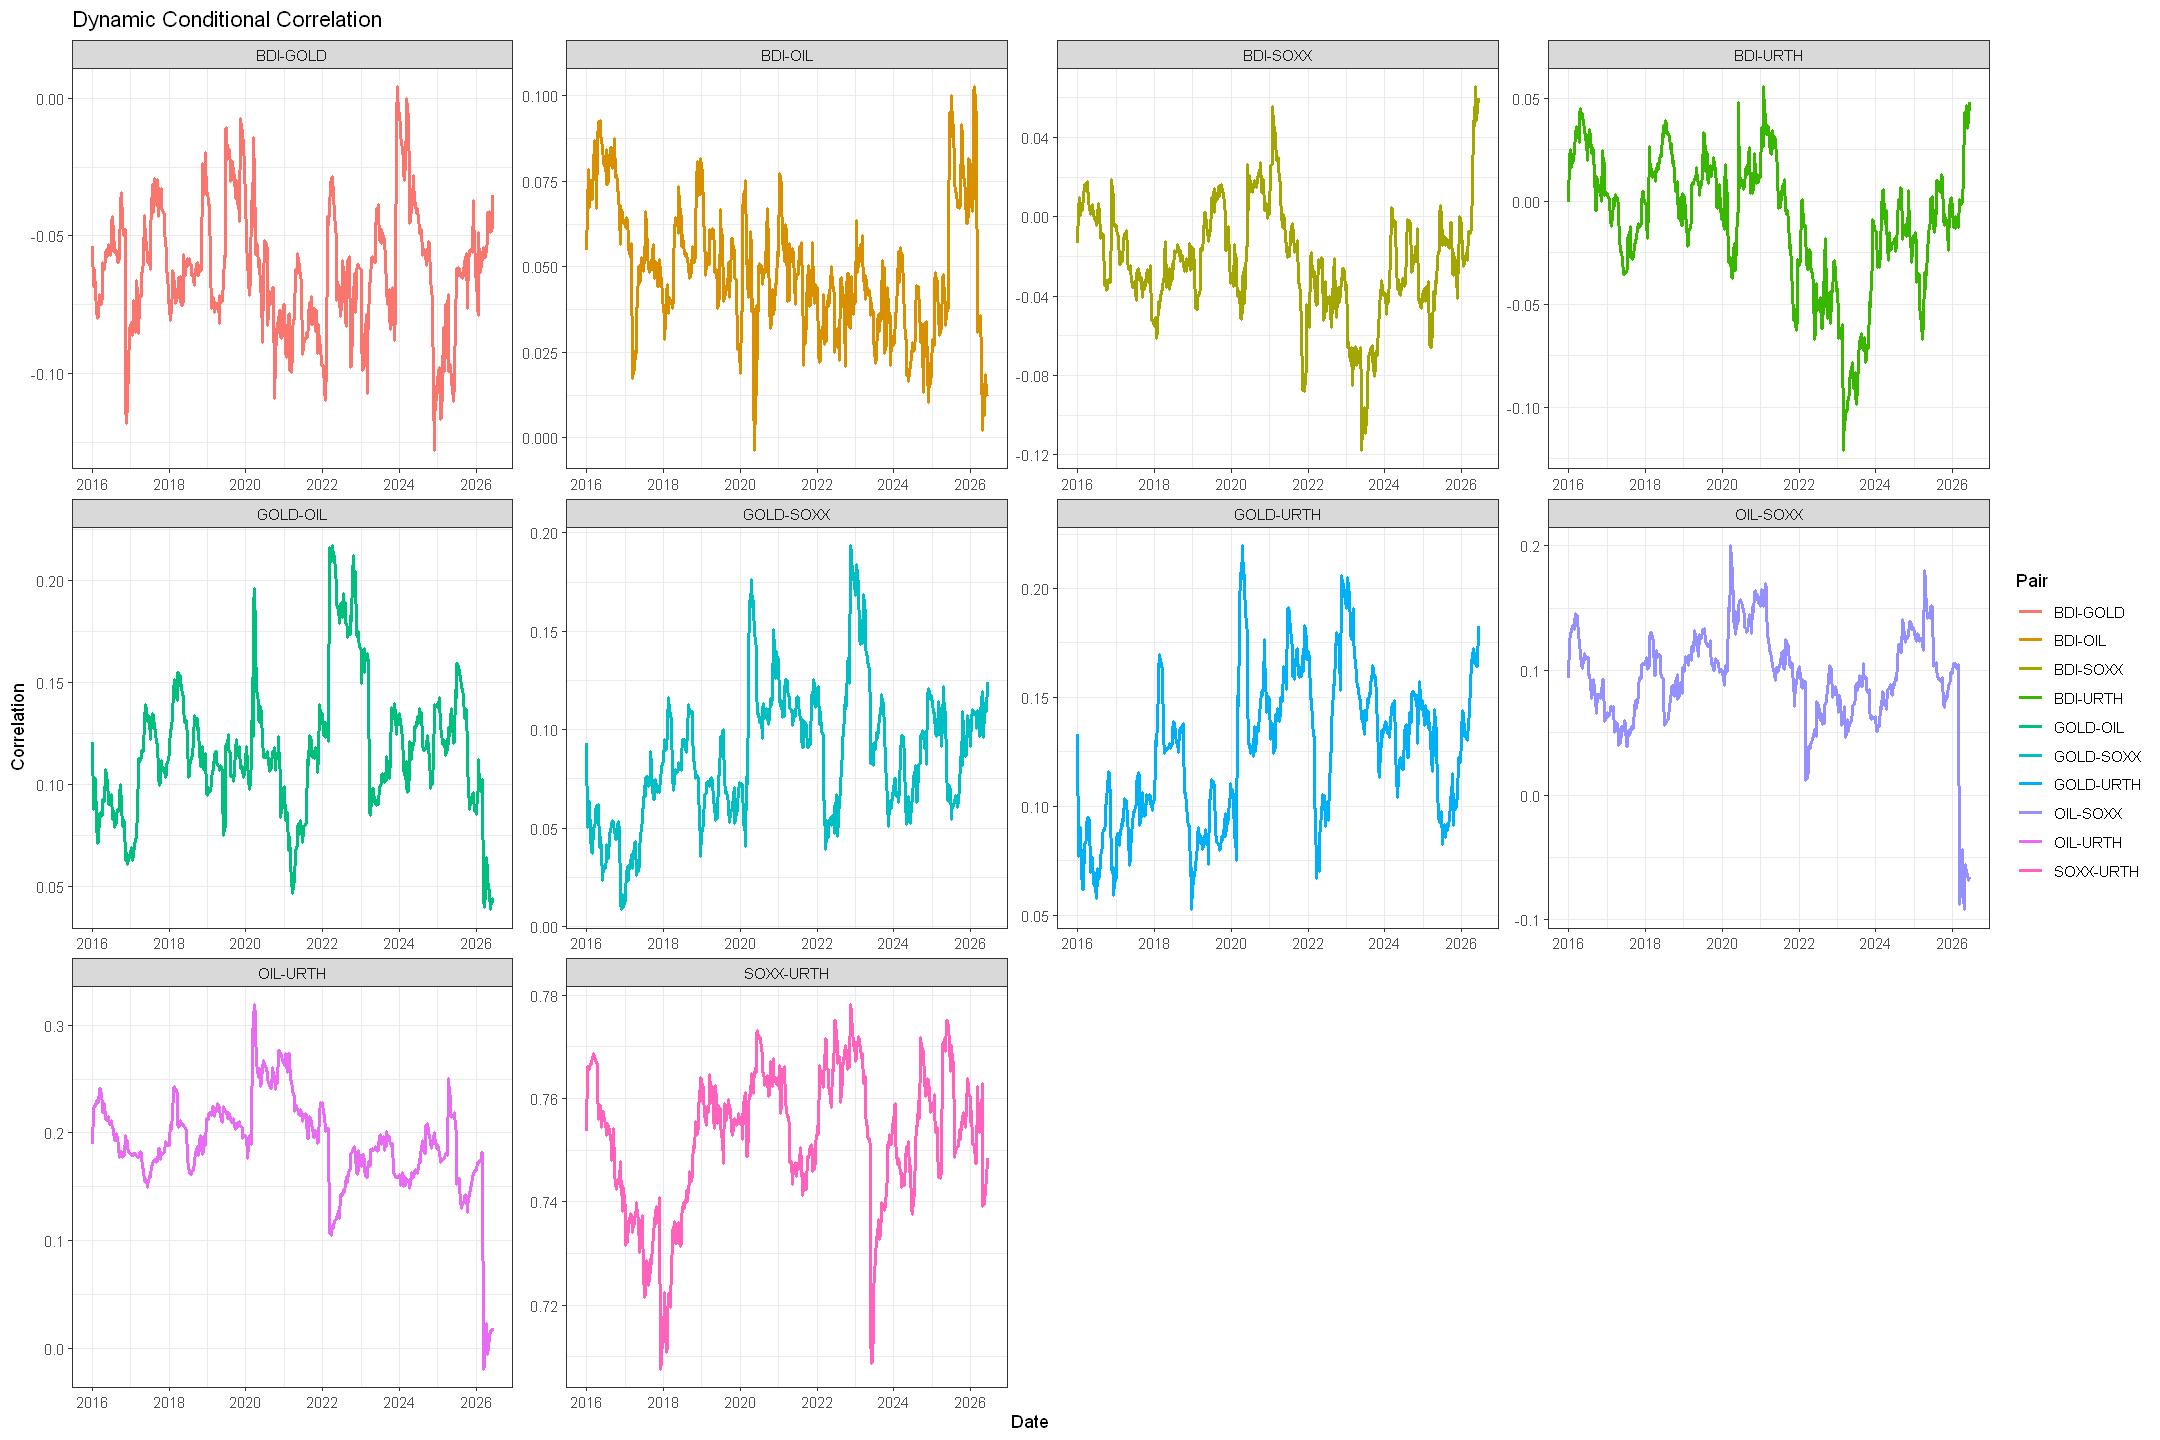

In [14]:
# Melt the correlation matrix
melt_corr_matrix <- melt(corr_matrix)

# Keep upper triangle
Rt_matrix <- subset(melt_corr_matrix, as.character(Var1) < as.character(Var2))

# Save conditional correlations of pairs to new data frame
Rt_matrix <- data.frame(Date = as.Date(Rt_matrix$Var3),
                        Pair = paste(Rt_matrix$Var1, Rt_matrix$Var2, sep="-"),
                        Corr_T = Rt_matrix$value)

# Time series plot of conditional correlation
options(repr.plot.width = 18, repr.plot.height = 12)
ggplot(Rt_matrix, aes(x = Date, y = Corr_T, color = Pair)) + 
    labs(title = "Dynamic Conditional Correlation", x = "Date", y = "Correlation") + 
    geom_line(size = 1) + 
    theme_bw() + 
    facet_wrap(~ Pair, scales = "free")

In [15]:
# Slice melted correlation matrix by date windows
pre_corr_matrix <- subset(melt_corr_matrix, as.character(Var3) < "2026-02-28")
pre_corr_matrix <- pre_corr_matrix %>%
        group_by(Var1, Var2) %>%
        summarise(mean_corr = mean(value), state = "1. Pre-Event (< 2026-02-28)")

esc_corr_matrix <- subset(melt_corr_matrix, as.character(Var3) > "2026-02-27" & as.character(Var3) < "2026-04-08")
esc_corr_matrix <- esc_corr_matrix %>%
        group_by(Var1, Var2) %>%
        summarise(mean_corr = mean(value), state = "2. Escalation (2026-02-28 - 2026-04-07)")

stb_corr_matrix <- subset(melt_corr_matrix, as.character(Var3) > "2026-04-07")
stb_corr_matrix <- stb_corr_matrix %>%
        group_by(Var1, Var2) %>%
        summarise(mean_corr = mean(value), state = "3. Stabilization (> 2026-04-08)")

# Stack lists vertically
full_corr_matrix <- bind_rows(pre_corr_matrix, esc_corr_matrix, stb_corr_matrix)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Var1 and Var2.
ℹ Output is grouped by Var1.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Var1, Var2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Var1 and Var2.
ℹ Output is grouped by Var1.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Var1, Var2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Var1 and Var2.
ℹ Output is grouped by Var1.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Var1, Var2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


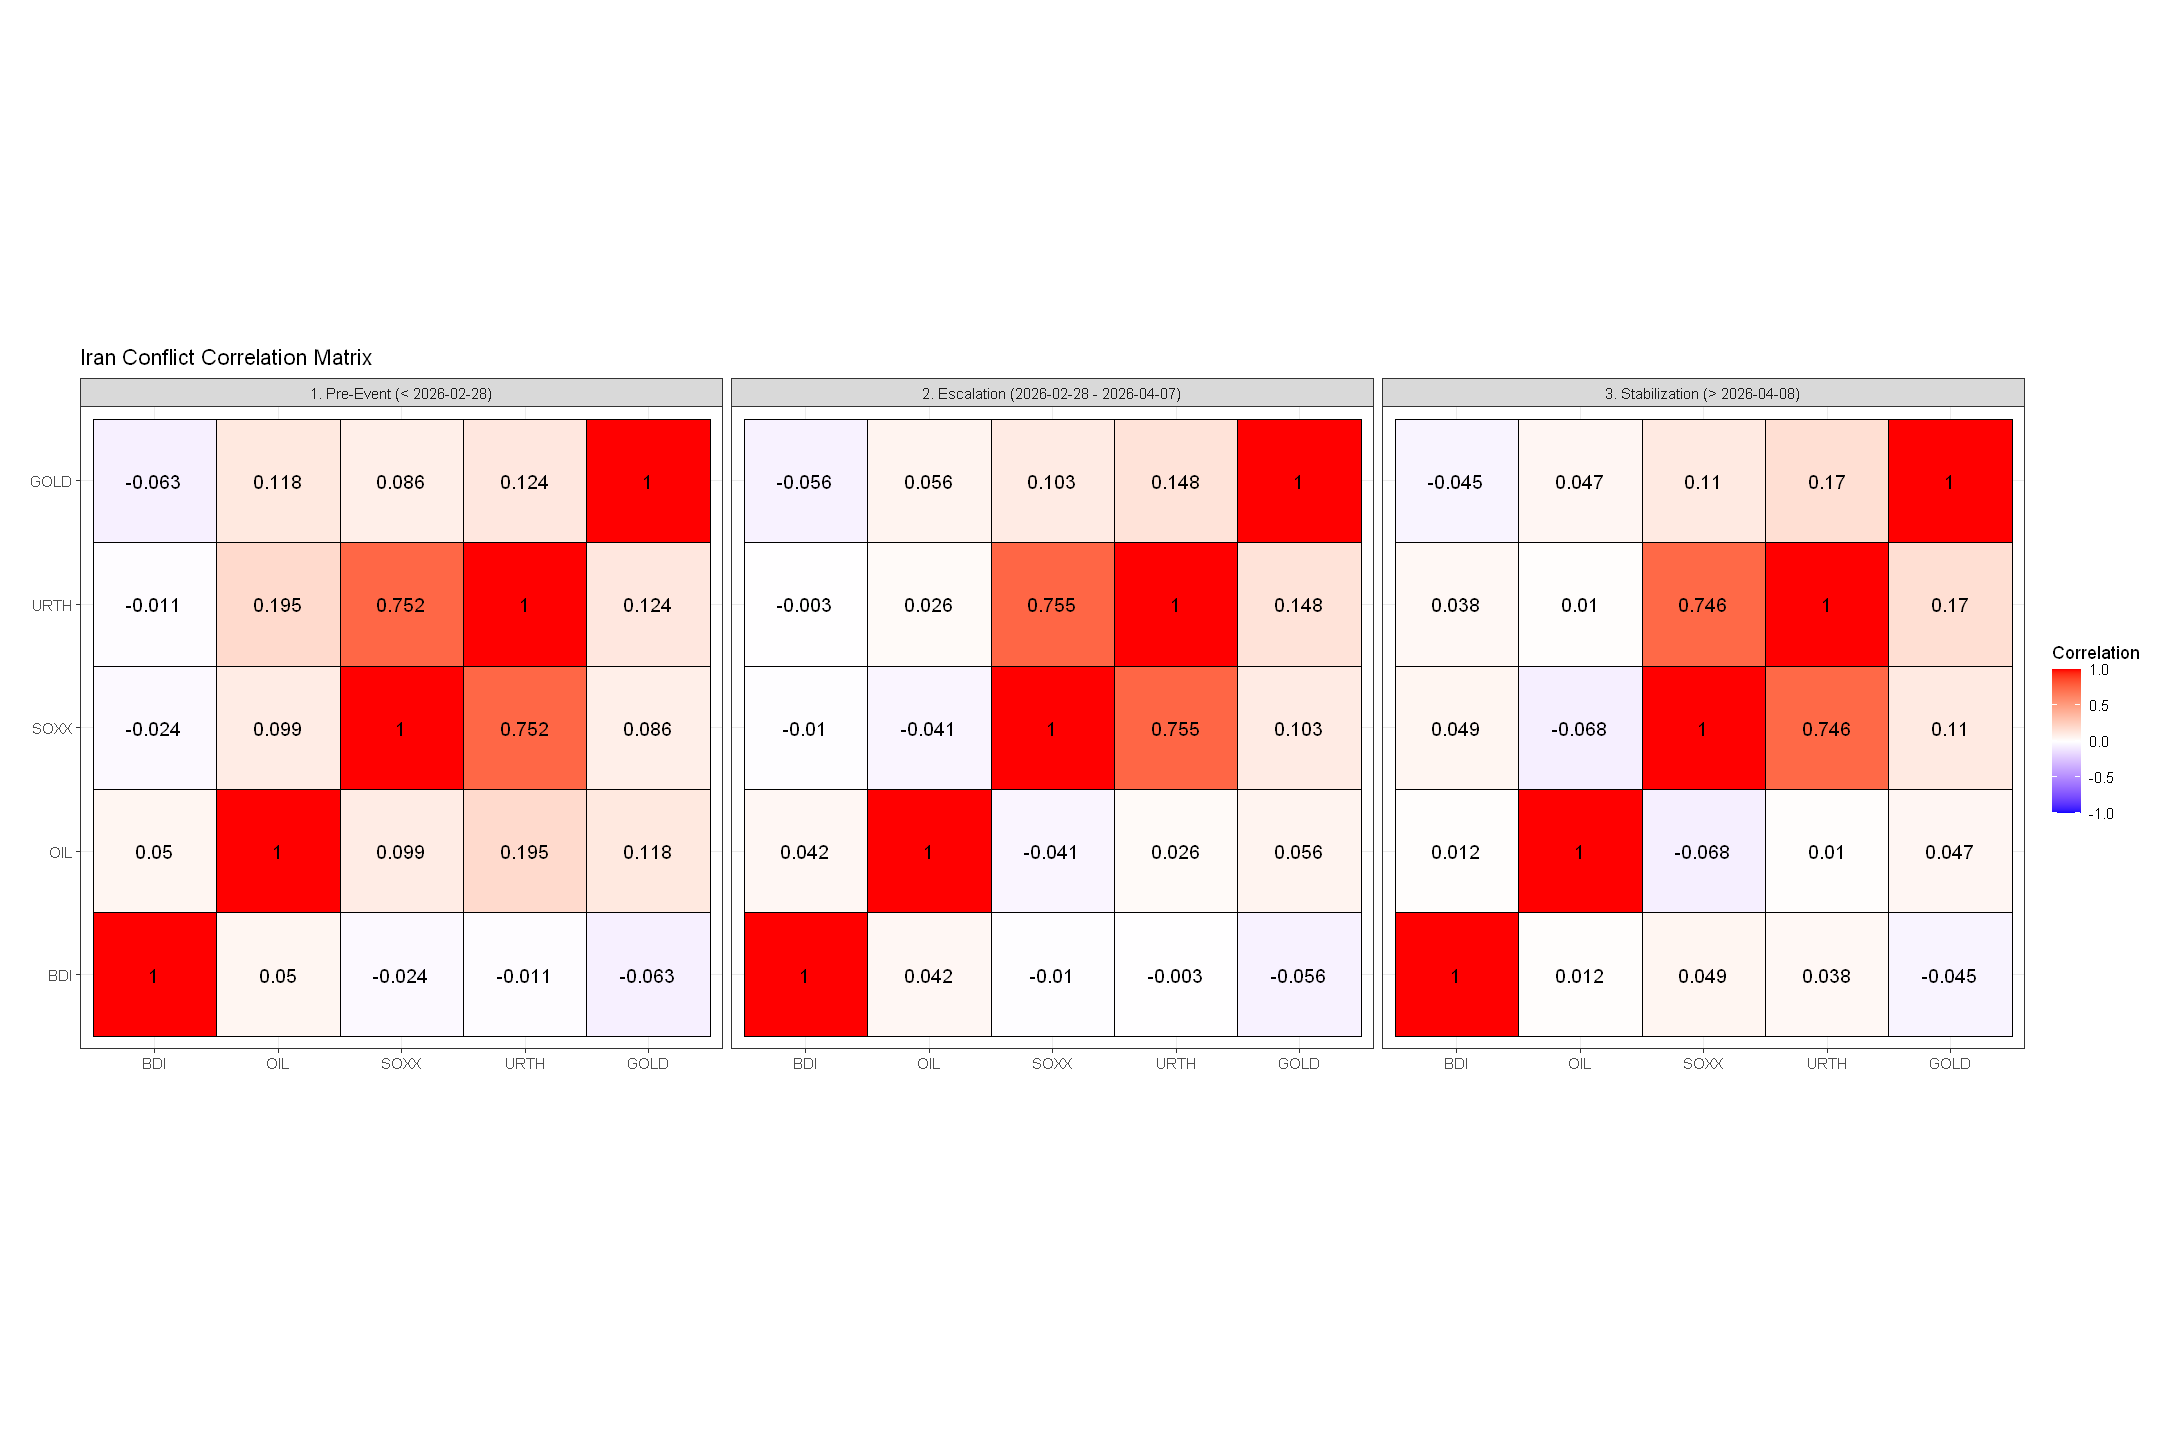

In [16]:
# Plot correlation matrix phases of all assets
ggplot(data = full_corr_matrix, aes(x = Var1, y = Var2, fill = mean_corr)) +
  geom_tile(color = "black", size = 0.1) + 
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", 
                       midpoint = 0, limit = c(-1,1), space = "Lab", 
                       name="Correlation") +
  geom_text(aes(label = round(mean_corr, 3)), 
          color = "black", size = 4) + 
  labs(x = "", y = "", title = "Iran Conflict Correlation Matrix") + 
  theme_bw() +
  coord_fixed() + 
  facet_wrap(~ state)